In [21]:
import mne
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mne.channels import make_dig_montage
import neurokit2 as nk
import scipy

In [22]:
data_path = ".\sub1\sub-001_ses-01_task-GXtESCTT_eeg.set"
raw = mne.io.read_raw_eeglab(data_path, preload=True)

Reading d:\Developer\EEG_dataset\sub1\sub-001_ses-01_task-GXtESCTT_eeg.fdt
Reading 0 ... 8455575  =      0.000 ...  4227.788 secs...


C:\Users\Jose\AppData\Local\Temp\ipykernel_16296\2235775890.py:2: RuntimeWarning: Estimated head radius (0.0 cm) is below the 3rd percentile for infant head size. Check if the montage_units argument is correct (the default is "mm", but your channel positions may be in different units).
  raw = mne.io.read_raw_eeglab(data_path, preload=True)


### Changing Channels types

In [23]:
non_eeg_channels = {
    'BIP1': 'ecg',
    'BIP2': 'eog', 
    'RESP1': 'resp'
}

raw.set_channel_types(non_eeg_channels)

<RawEEGLAB | sub-001_ses-01_task-GXtESCTT_eeg.fdt, 35 x 8455576 (4227.8 s), ~2.21 GiB, data loaded>

### Setting Montage

Setting electrodes montage and fixing the rotation for the display

In [24]:
montage = mne.channels.read_custom_montage("sub1\sub-001_ses-01_task-GXtESCTT_electrodes.tsv", coord_frame="head")
raw.set_montage(montage, on_missing='warn', match_case=False)

<RawEEGLAB | sub-001_ses-01_task-GXtESCTT_eeg.fdt, 35 x 8455576 (4227.8 s), ~2.21 GiB, data loaded>

In [25]:
montage_rotated = raw.get_montage()

pos = montage_rotated.get_positions()
ch_pos = pos['ch_pos']

theta = np.pi / 2
R = np.array([
    [ np.cos(theta), -np.sin(theta), 0],
    [ np.sin(theta),  np.cos(theta), 0],
    [             0,              0, 1]
])

ch_pos_rotated = {ch: R @ coord for ch, coord in ch_pos.items()}

montage_rotated = mne.channels.make_dig_montage(
    ch_pos=ch_pos_rotated,
    coord_frame='head'
)

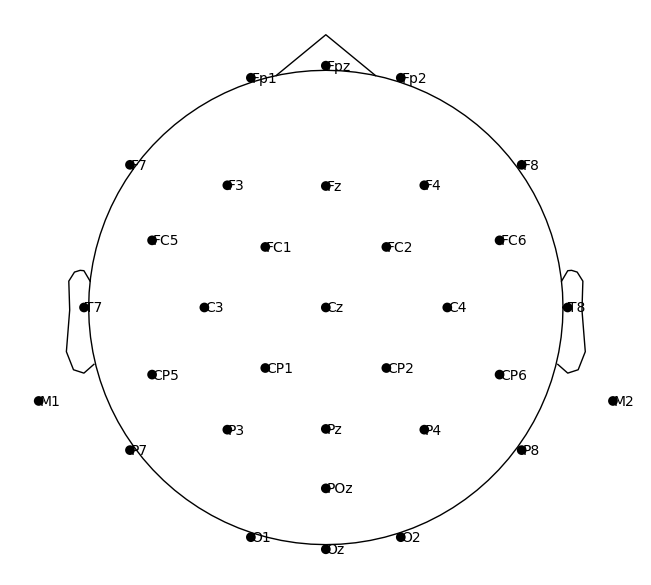

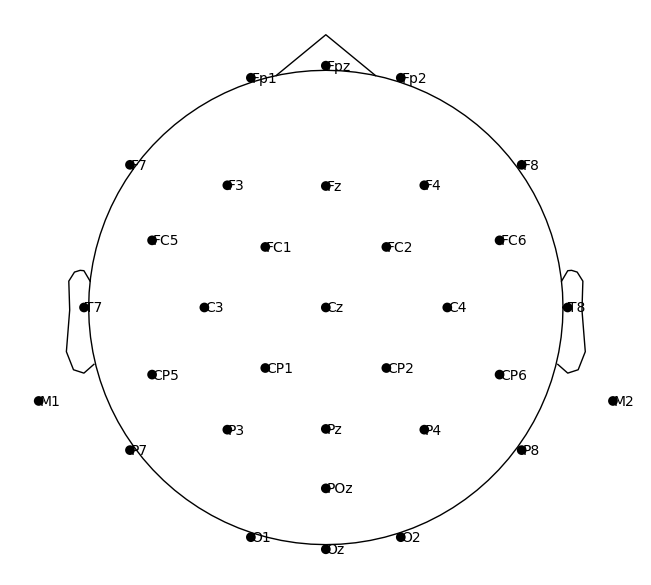

In [26]:
raw.set_montage(montage_rotated, on_missing='warn', match_case=False)
raw.plot_sensors(show_names=True, sphere=1)

# Signal visualization

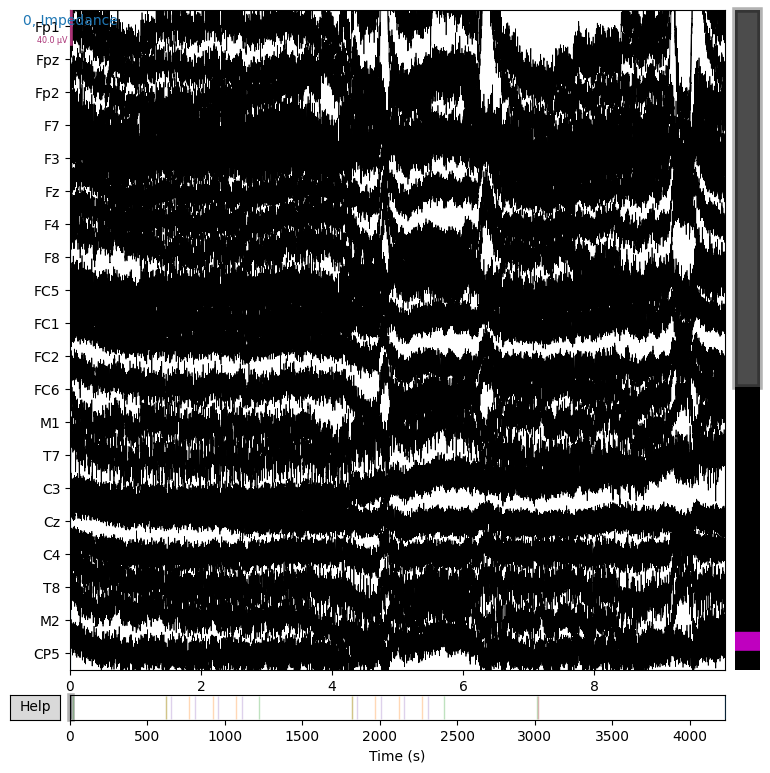

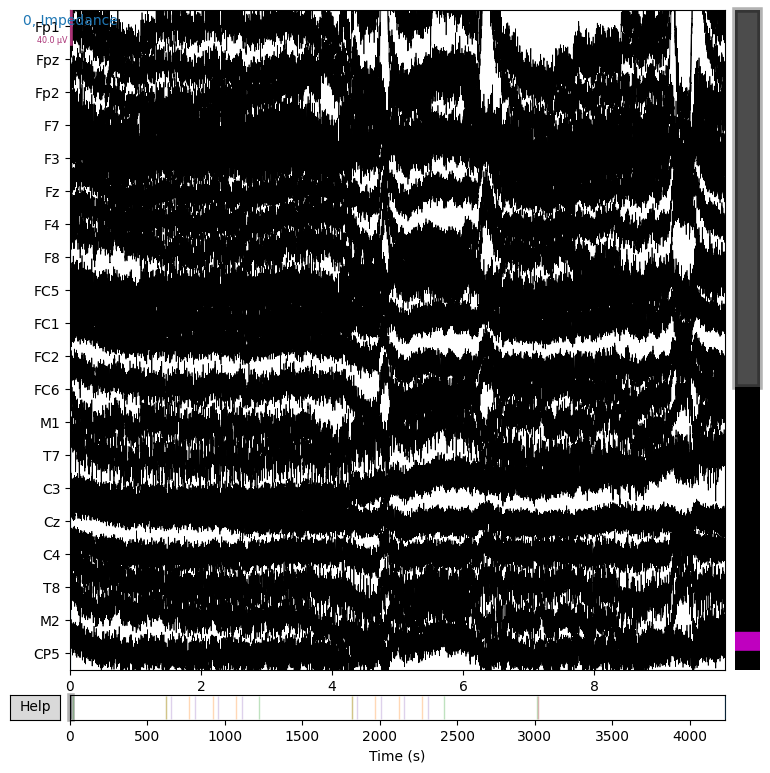

In [27]:
raw.plot()

## Signal Pre-Processing

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.


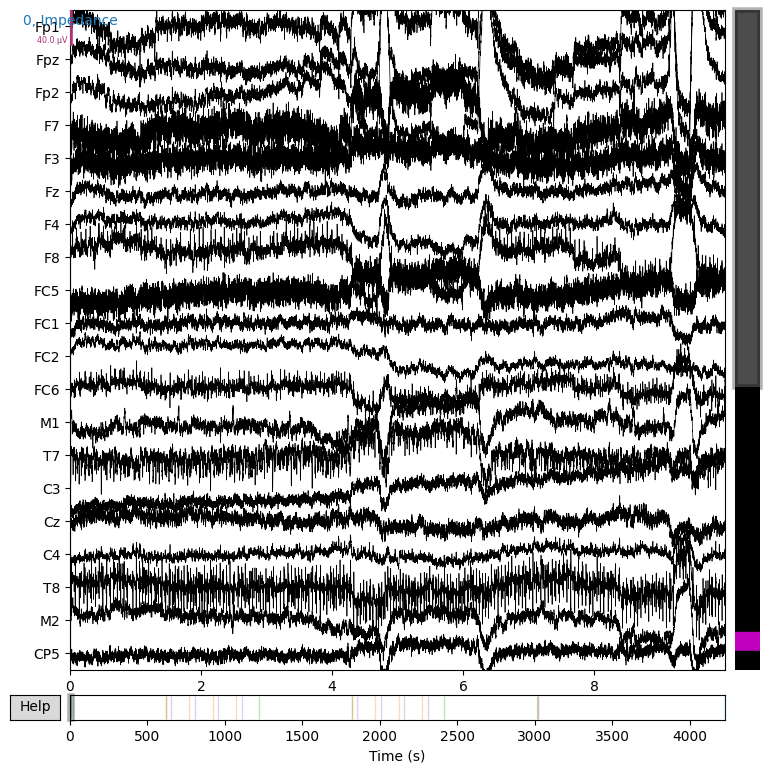

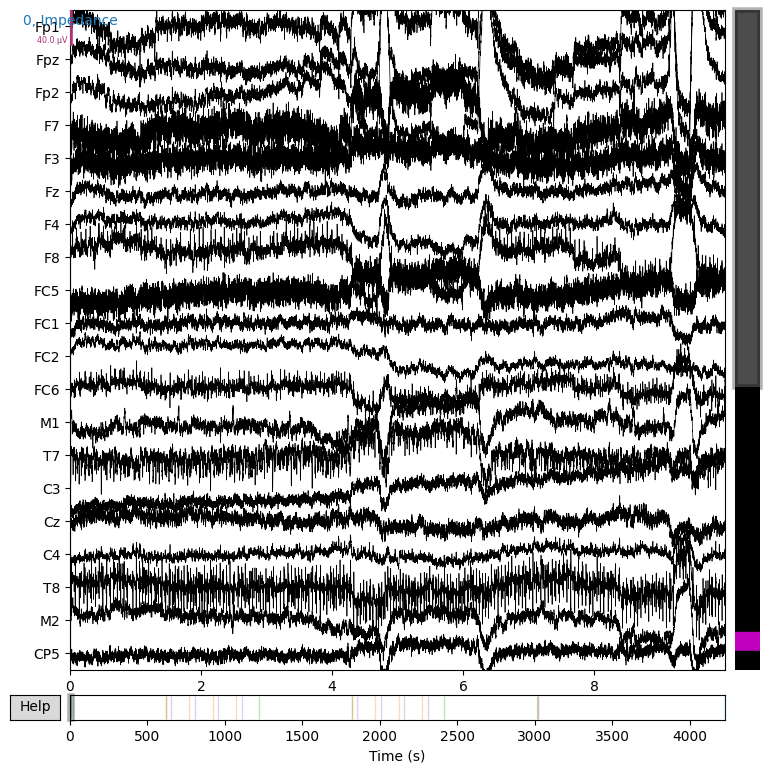

In [28]:
raw = raw.set_eeg_reference("average")
raw.plot()

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 60 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 60.00 Hz
- Upper transition bandwidth: 15.00 Hz (-6 dB cutoff frequency: 67.50 Hz)
- Filter length: 6601 samples (3.300 s)



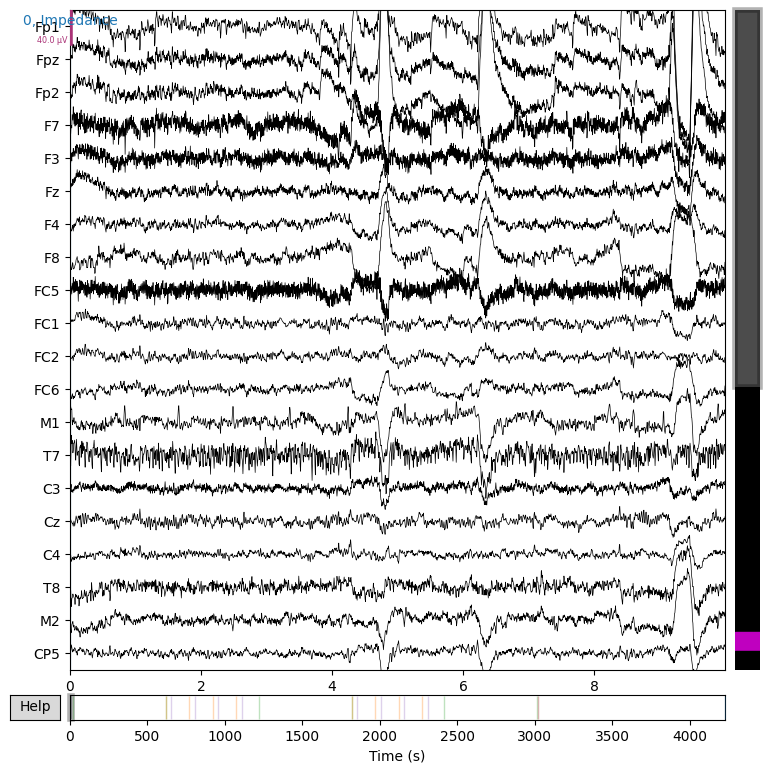

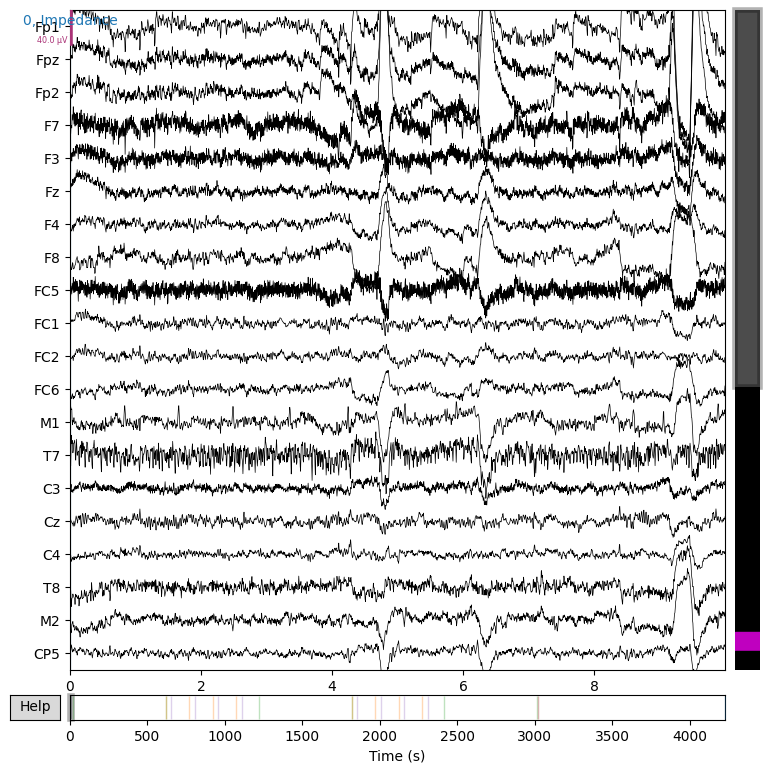

In [29]:
raw_filtered = raw.filter(l_freq=1, h_freq=60)
# raw_filtered = raw.copy().notch_filter(30)
raw_filtered.plot()

# Events and Stimulation

The dataset contains 4 event types:

| Code | Description              |
|------|--------------------------|
| 0    | Start/end of experiment  |
| 2    | Start/end of a resting block |
| 16   | Start of stimulation     |
| 32   | End of stimulation       |

Each block uses a different stimulation type.

In [30]:
def extract_events(raw):
  events, _ = mne.events_from_annotations(raw)
  map_event = {1:"Impedance", 3:"Block Start", 2: "Stim Start", 4:"Stim Stop"}
  events_df = pd.DataFrame(events, columns=["onset", "sample", "code"]).drop("sample", axis=1)

  sfreq = raw.info["sfreq"]
  events_df["time"] = events_df["onset"] / sfreq

  events_df["trigger"] = [map_event.get(i) for i in events_df["code"]]
  return events_df

print("Events extracted:")
print(extract_events(raw).head(10))

Events extracted:
Used Annotations descriptions: [np.str_('0, Impedance'), np.str_('16'), np.str_('2'), np.str_('32')]
     onset  code       time      trigger
0        0     1     0.0000    Impedance
1    40858     3    20.4290  Block Start
2  1238885     3   619.4425  Block Start
3  1238999     2   619.4995   Stim Start
4  1309493     4   654.7465    Stim Stop
5  1541032     2   770.5160   Stim Start
6  1611143     4   805.5715    Stim Stop
7  1843032     2   921.5160   Stim Start
8  1913304     4   956.6520    Stim Stop
9  2145103     2  1072.5515   Stim Start


### Extracting trials

Each trial goes from a stimulation start trigger till as stimulation stop trigger, and a sucessful trial should have around 30s of duration

In [31]:
def extract_tdcs_trials(raw):
	events_df = extract_events(raw)

	trials = []

	events_start = events_df[events_df["trigger"] == "Stim Start"]
	events_stop = events_df[events_df["trigger"] == "Stim Stop"]

	for i, (_, row_start) in enumerate(events_start.iterrows()):
		if i > len(events_stop):
			continue
		
		row_stop = events_stop.iloc[i]
		if row_stop['time'] - row_start['time'] < 20:
			continue
		else:
			trials.append({
					'onset': [row_start["onset"], row_stop["onset"]],
					'time': [row_start["time"], row_stop["time"]],
					'duration': row_stop['time'] - row_start['time']
			})
	return trials

trials = extract_tdcs_trials(raw)
len(trials)

Used Annotations descriptions: [np.str_('0, Impedance'), np.str_('16'), np.str_('2'), np.str_('32')]


8

In [32]:
trials

[{'onset': [1238999, np.int64(1309493)],
  'time': [619.4995, np.float64(654.7465)],
  'duration': np.float64(35.24699999999996)},
 {'onset': [1541032, np.int64(1611143)],
  'time': [770.516, np.float64(805.5715)],
  'duration': np.float64(35.05550000000005)},
 {'onset': [1843032, np.int64(1913304)],
  'time': [921.516, np.float64(956.652)],
  'duration': np.float64(35.13600000000008)},
 {'onset': [2145103, np.int64(2215158)],
  'time': [1072.5515, np.float64(1107.579)],
  'duration': np.float64(35.02749999999992)},
 {'onset': [3639188, np.int64(3709778)],
  'time': [1819.594, np.float64(1854.889)],
  'duration': np.float64(35.294999999999845)},
 {'onset': [3941340, np.int64(4011432)],
  'time': [1970.67, np.float64(2005.716)],
  'duration': np.float64(35.04599999999982)},
 {'onset': [4243290, np.int64(4313392)],
  'time': [2121.645, np.float64(2156.696)],
  'duration': np.float64(35.05099999999993)},
 {'onset': [4545513, np.int64(4615598)],
  'time': [2272.7565, np.float64(2307.799)],

In [33]:
def extract_channel(raw, channels):
  data = {}
  for ch in channels:
    ch_data, times = raw[ch, :]
    data[ch] = ch_data.flatten()

  df = pd.DataFrame(data)
  df.index = times
  df['time'] = times
  return df

In [34]:
channels = extract_channel(raw, ['Fp1', 'CP1'])
channels

,Fp1,CP1,time
0.0000,-1.843144e-18,-1.151965e-19,0.0000
0.0005,-2.180828e-09,3.567815e-07,0.0005
0.0010,1.640719e-09,7.067261e-07,0.0010
0.0015,1.675525e-08,1.043355e-06,0.0015
0.0020,4.897510e-08,1.360170e-06,0.0020
...,...,...,...
4227.7855,4.624466e-06,6.522476e-06,4227.7855
4227.7860,3.461349e-06,4.976890e-06,4227.7860
4227.7865,2.304154e-06,3.359107e-06,4227.7865
4227.7870,1.150970e-06,1.692004e-06,4227.7870


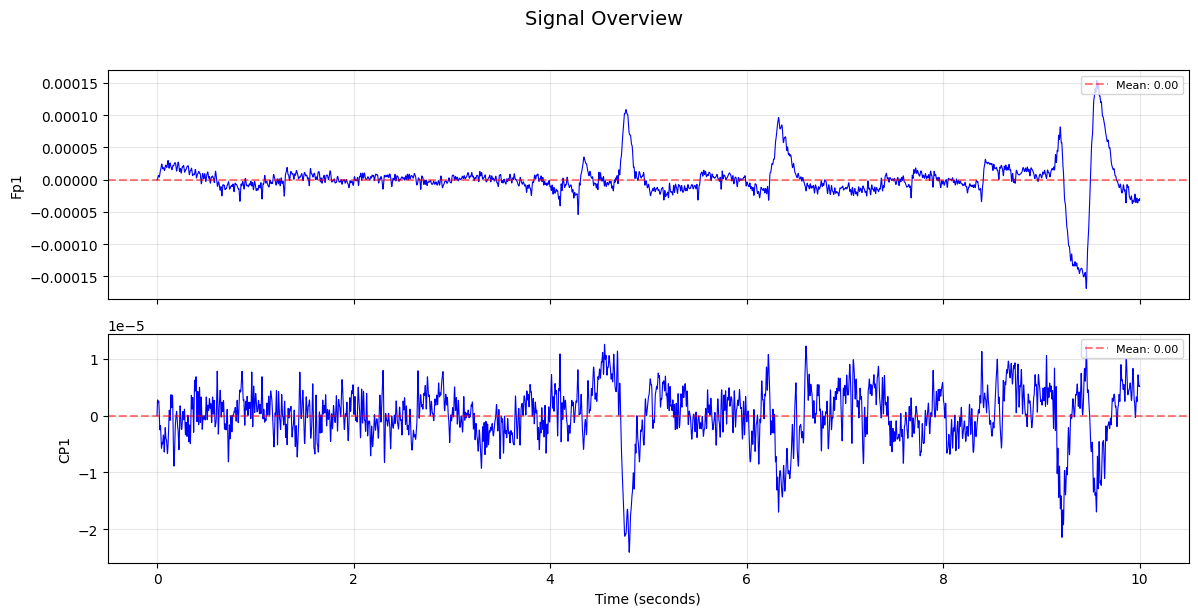

In [35]:
def plot_channels(df, sfreq, duration=4):
    """Plot first 'duration' seconds of physio data"""
    time_limit = min(duration, len(df) / sfreq)
    mask = df['time'] <= time_limit
    
    cols = [col for col in df.columns if col != 'time']
    n_channels = len(cols)
    
    
    fig, axes = plt.subplots(n_channels, 1, figsize=(12, 3*n_channels), sharex=True)
    if n_channels == 1:
        axes = [axes]
    
    for i, channel in enumerate(cols):
        axes[i].plot(df['time'][mask], df[channel][mask], 
                     linewidth=0.8, color='b')
        axes[i].set_ylabel(channel, fontsize=10)
        axes[i].grid(True, alpha=0.3)
        
        mean_val = df[channel].mean()
        std_val = df[channel].std()
        axes[i].axhline(mean_val, color='r', linestyle='--', alpha=0.5, 
                       label=f'Mean: {mean_val:.2f}')
        axes[i].legend(fontsize=8, loc="upper right")
    
    axes[-1].set_xlabel('Time (seconds)', fontsize=10)
    plt.suptitle('Signal Overview', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


plot_channels(channels, raw.info["sfreq"], duration=10)

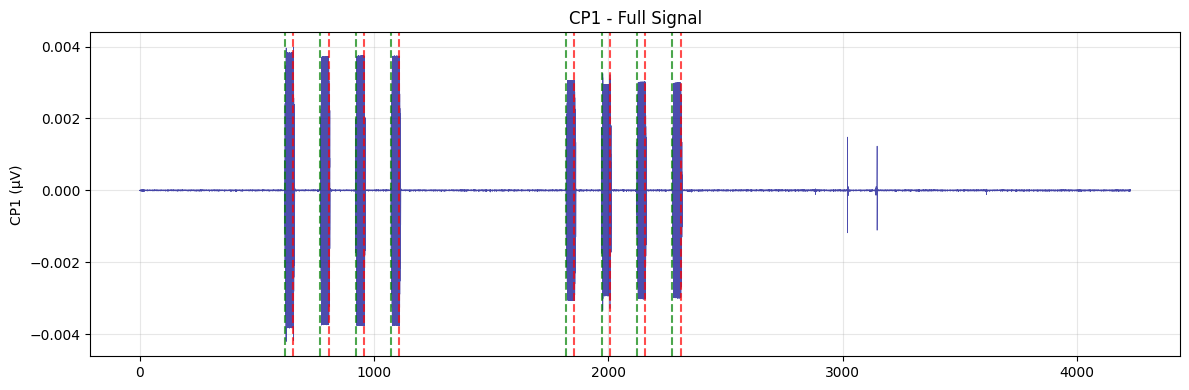

In [36]:
def plot_triggers(channels_df, channel_name):
    """Plot individual physiological channel with statistics"""
    if channel_name not in channels_df.columns:
        print(f"Channel {channel_name} not found")
        return
    
    fig, (ax1) = plt.subplots(1, 1, figsize=(12, 4))
    
    # Full signal
    ax1.plot(channels_df['time'], channels_df[channel_name], 
             linewidth=0.5, color='darkblue', alpha=0.7)
    ax1.set_ylabel(f'{channel_name} (µV)', fontsize=10)
    ax1.set_title(f'{channel_name} - Full Signal', fontsize=12)
    ax1.grid(True, alpha=0.3)

    for trial in trials:
        ax1.axvline(trial['time'][0], color='green', linestyle='--', 
                linewidth=1.5, alpha=0.7, label='Start')
        ax1.axvline(trial['time'][1], color='red', linestyle='--', 
                linewidth=1.5, alpha=0.7, label='Start')
        
    
    plt.tight_layout()
    plt.show()

plot_triggers(channels, 'CP1')

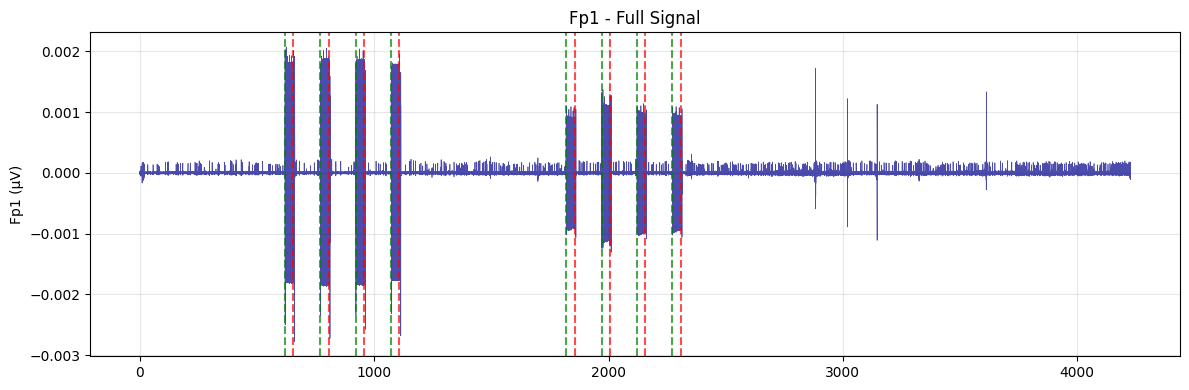

In [41]:
# channels_filtered = extract_channel(raw_filtered, ['Fp1', 'CP1'])
plot_triggers(channels, 'Fp1')

## Basic Analysis

In [38]:
def extract_channel(channel):
    ecg_channels = [ch for ch in raw.ch_names if channel in ch.upper()]
    if ecg_channels:
        ecg_channel = ecg_channels[0]
        print(f"Using ECG channel: {ecg_channel}")
        
        # Extract full ECG data
        data, times = raw[ecg_channel, :]
        data = data.flatten()
        sampling_rate = raw.info['sfreq']
        
        print(f"ECG data shape: {data.shape}")
        print(f"Sampling rate: {sampling_rate} Hz")
        return data, times

data, times = extract_channel("FP1")

Using ECG channel: Fp1
ECG data shape: (8455576,)
Sampling rate: 2000.0 Hz


In [ ]:
def extract_stim_ecg_epochs(trials, data, times, sampling_rate, duration=30):
    """Extract ECG epochs before each trial onset using NeuroKit2"""
    epochs = []
    
    for trial in trials:
        start_time = trial['time'][0]
        end_time = trial['time'][1]
        
        # Find indices
        start_idx = int(start_time * sampling_rate)
        end_idx = int(end_time * sampling_rate)
        ramp_down = int(6*sampling_rate)
        
        # Extract epoch
        pre_signal = data[start_idx - int(duration*sampling_rate):start_idx]
        stim_signal = data[start_idx:end_idx + ramp_down]
        pos_signal = data[end_idx + ramp_down:end_idx + int(duration*sampling_rate) + ramp_down]

        pre_times = times[start_idx - int(duration*sampling_rate):start_idx]
        stim_times = times[start_idx:end_idx + ramp_down] # Center at 0 (trial onset)
        pos_times = times[end_idx + ramp_down:end_idx + int(duration*sampling_rate) + ramp_down]
        
        epochs.append({
            'signal': [pre_signal, stim_signal, pos_signal],
            'times': [pre_times, stim_times, pos_times],
            'duration': duration
        })
    
    return epochs

In [ ]:
stim_epochs = extract_stim_ecg_epochs(trials, data, times, raw.info["sfreq"])

### Stimulation Analysis

In [49]:
def plot_epochs(epoch):
	fig = plt.figure(figsize=(12, 8), layout="constrained")
	spec = fig.add_gridspec(3, 3)

	for i in range(3):
		if i == 0:
			signal_label = "Pre-"
		elif i == 1:
			signal_label = ""
		else:
			signal_label = "Pos-" 

		ax = fig.add_subplot(spec[0,i])
		ax.axhline(np.mean(epoch["signal"][i]), color="red")
		ax.plot(epoch['times'][i], epoch['signal'][i], 
						linewidth=0.5, color='darkblue', alpha=0.7)
		ax.set_title(f'{signal_label}Stimulation', fontsize=10)
		ax.set_xlabel('Time (s)')
		ax.set_ylabel('Amplitude')
		
		ax = fig.add_subplot(spec[1,i])
		fs = 1 / (epoch['times'][i][1] - epoch['times'][i][0])

		data = epoch['signal'][i]
		f, t, Sxx = scipy.signal.spectrogram(data, fs, 
														nperseg=min(256, len(data)//2),
														noverlap=128,
														scaling='density')
		
		im = ax.pcolormesh(t, f, 10 * np.log10(Sxx + 1e-10), 
											shading='gouraud', cmap='jet')
		ax.set_title(f'{signal_label}Stymlus Spectrogram', fontsize=10)
		ax.set_xlabel('Time (s)')
		ax.set_ylabel('Frequency (Hz)')
		ax.set_ylim([0, min(fs/2, 50)]) 

	full_signal = np.concatenate(epoch["signal"])
	full_times = np.concatenate(epoch['times'])
	
	overall_mean = np.mean(full_signal)

	ax = fig.add_subplot(spec[2, :])
	ax.plot(full_times, full_signal, linewidth=0.5, color='darkgreen', alpha=0.7)
	ax.axhline(y=overall_mean, color='red', linestyle='--', linewidth=1, alpha=0.8)

	plt.title("Signal")

	fig.suptitle("Signal Close-up during stimulation", x=0.53, fontsize=14)

	plt.tight_layout()
	plt.show()

C:\Users\Jose\AppData\Local\Temp\ipykernel_16296\1350393344.py:50: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


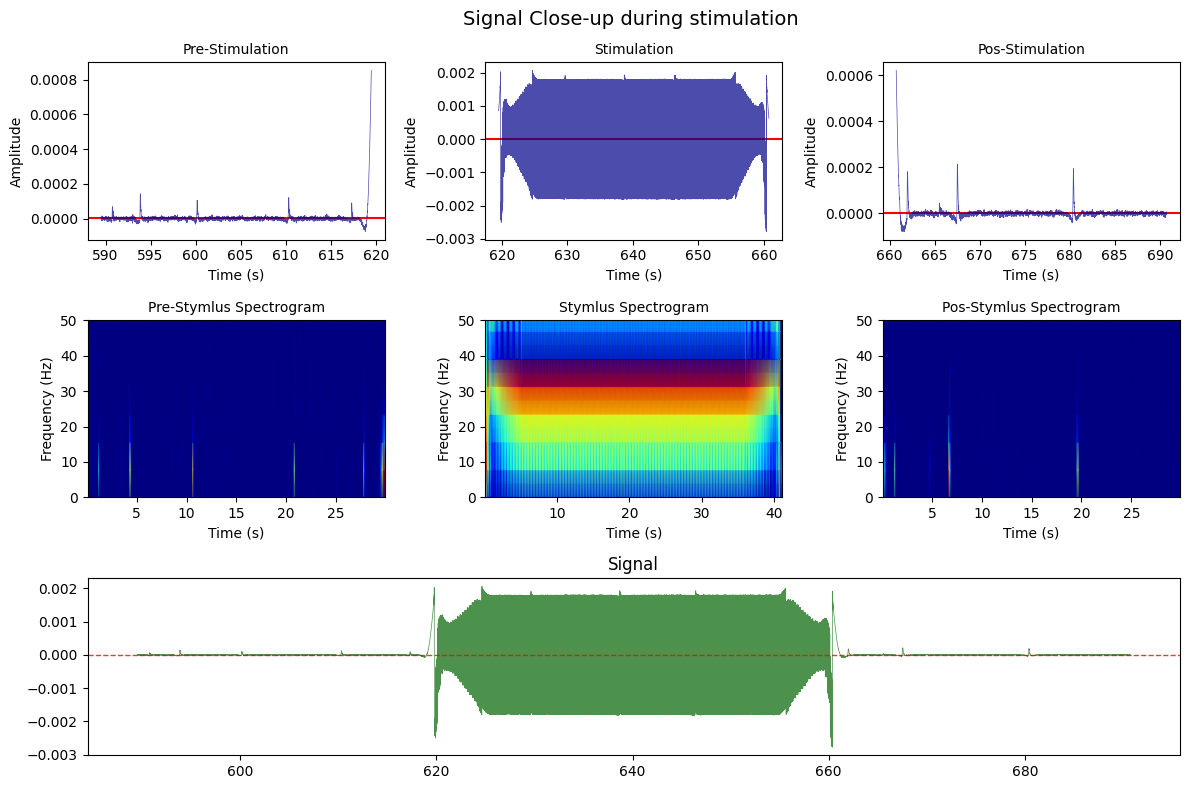

In [50]:
plot_epochs(stim_epochs[0])

C:\Users\Jose\AppData\Local\Temp\ipykernel_16296\1350393344.py:50: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


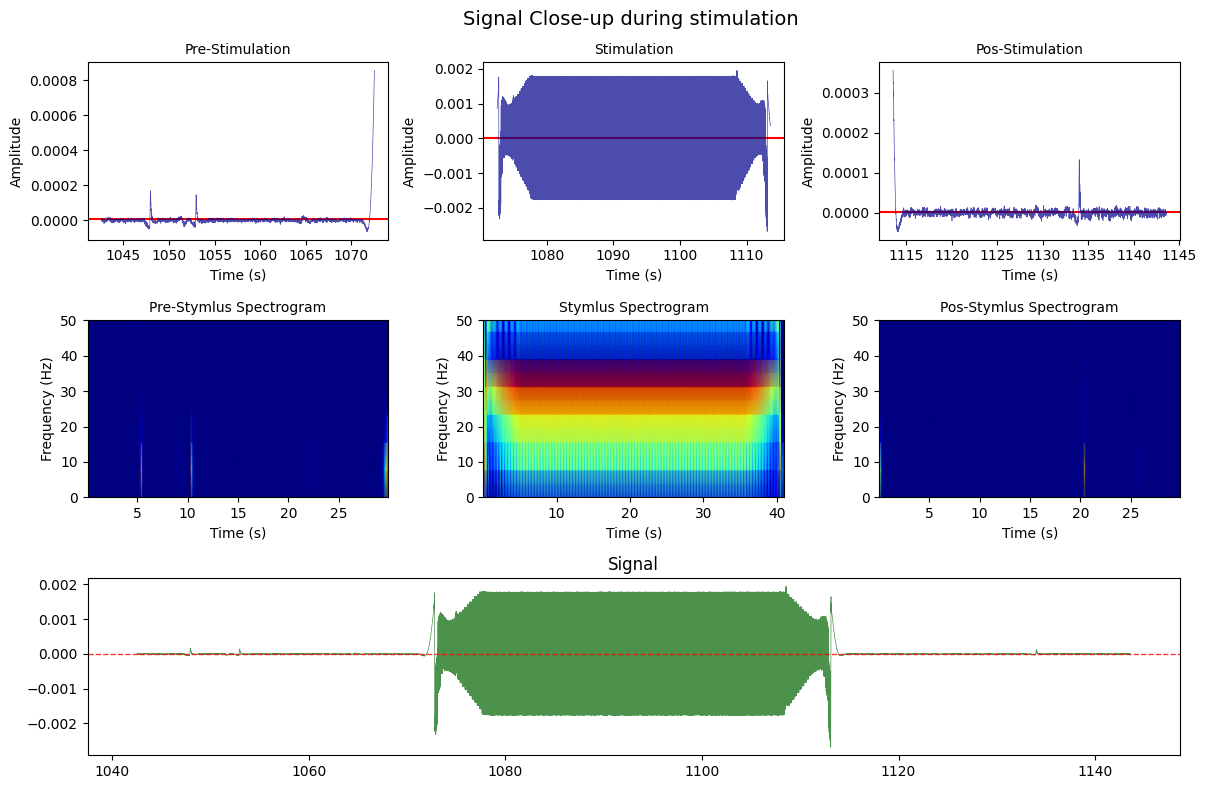

In [51]:
plot_epochs(stim_epochs[3])

C:\Users\Jose\AppData\Local\Temp\ipykernel_16296\1350393344.py:50: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


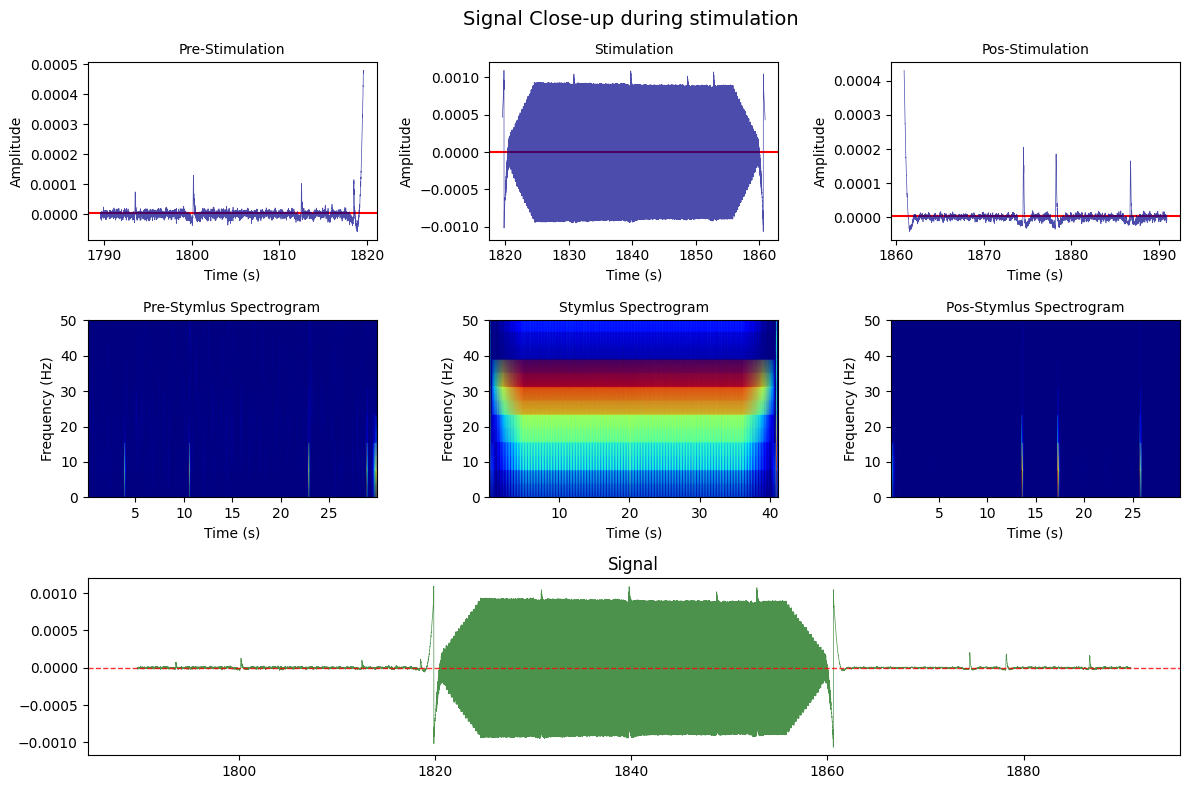

In [52]:
plot_epochs(stim_epochs[4])

## ECG analysis

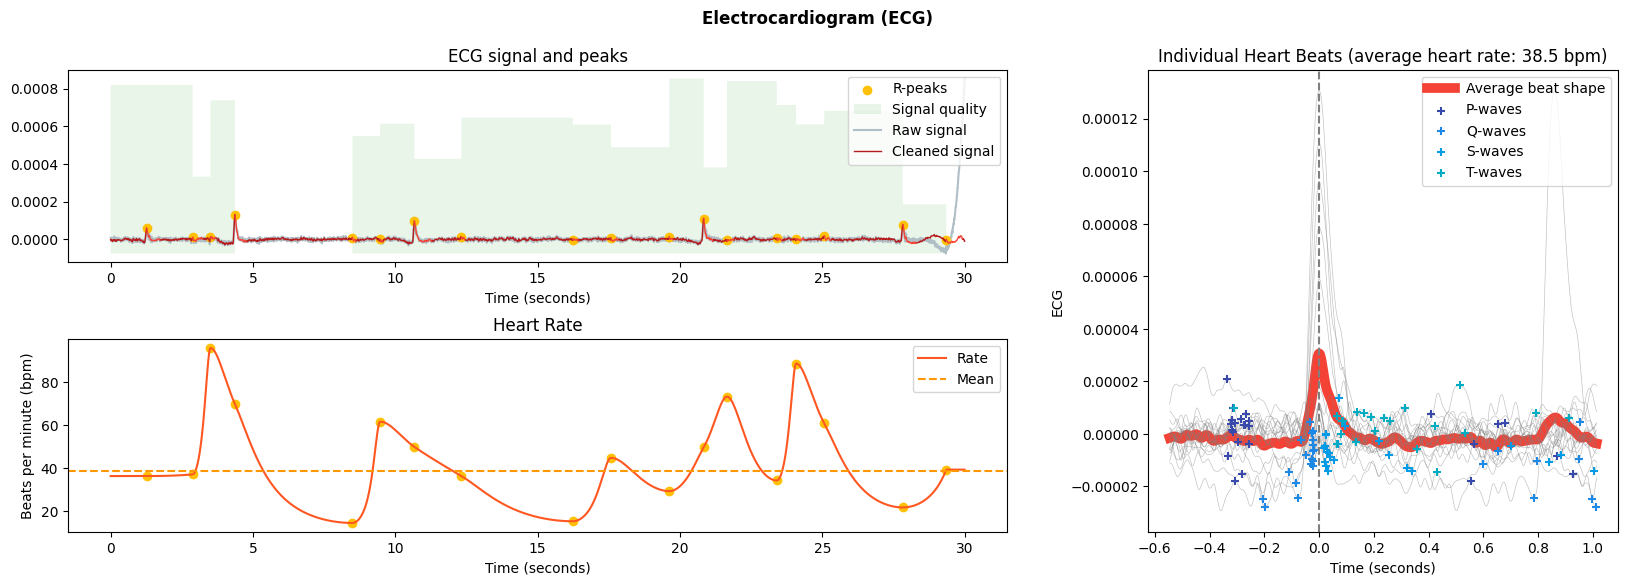

Processed 1 epochs


In [55]:
def process_ecg_epochs(epochs, sampling_rate, stim_moment=0):
    """Process each ECG epoch using NeuroKit2"""
    processed_epochs = []
    
    for epoch in epochs:
        # Use NeuroKit2's complete ECG processing pipeline [citation:2][citation:9]
        signals, info = nk.ecg_process(
            epoch['signal'][stim_moment], 
            sampling_rate=sampling_rate
        )
        nk.ecg_plot(signals, info)
        
        fig = plt.gcf()
        fig.set_size_inches(20, 6)
        plt.subplots_adjust(hspace=0.4)
        plt.show()
        
        processed_epochs.append({
            'signals': signals,
            'info': info,
            'times': epoch['times']
        })
    
    return processed_epochs

# Process all pre-stimulus epochs
processed_epochs = process_ecg_epochs(stim_epochs[:1], raw.info["sfreq"])
print(f"Processed {len(processed_epochs)} epochs")

In [57]:
def extract_heartbeat_features(processed_epochs, sampling_rate):
    """Extract R-peaks and heart rate features"""
    all_rpeaks = []
    all_heart_rates = []
    
    for epoch in processed_epochs:
        # R-peak locations (in samples) from NeuroKit2 [citation:3][citation:10]
        rpeaks = epoch['info']['ECG_R_Peaks']
        
        # Convert to time (relative to epoch start)
        rpeak_times = rpeaks / sampling_rate
        
        # Calculate instantaneous heart rate
        if len(rpeaks) > 1:
            # RR intervals in milliseconds
            rr_intervals = np.diff(rpeaks) / sampling_rate * 1000
            heart_rate = 60000 / rr_intervals  # bpm
        else:
            heart_rate = []
            rr_intervals = []
        
        all_rpeaks.append({
            'rpeak_indices': rpeaks,
            'rpeak_times': rpeak_times,
            'rr_intervals': rr_intervals,
            'heart_rate': heart_rate
        })
        
        # Calculate mean heart rate for this epoch
        if len(rr_intervals) > 0:
            mean_hr = np.mean(60000 / rr_intervals)
        else:
            mean_hr = np.nan
        all_heart_rates.append(mean_hr)
    
    return all_rpeaks, all_heart_rates

rpeaks_data, heart_rates = extract_heartbeat_features(processed_epochs, raw.info["sfreq"])

c:\Python310\lib\site-packages\neurokit2\hrv\hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
c:\Python310\lib\site-packages\neurokit2\complexity\entropy_multiscale.py:346: RuntimeWarning: invalid value encountered in scalar divide
  mse = np.trapezoid(mse) / len(mse)
c:\Python310\lib\site-packages\neurokit2\complexity\optim_complexity_k.py:134: RuntimeWarning: divide by zero encountered in divide
  normalization = (n - 1) / (np.floor((n - k_subrange) / k).astype(int) * k)
c:\Python310\lib\site-packages\neurokit2\complexity\optim_complexity_k.py:135: RuntimeWarning: invalid value encountered in multiply
  sets = (np.nansum(np.abs(np.diff(sig_values)), axis=1) * normalization) / k


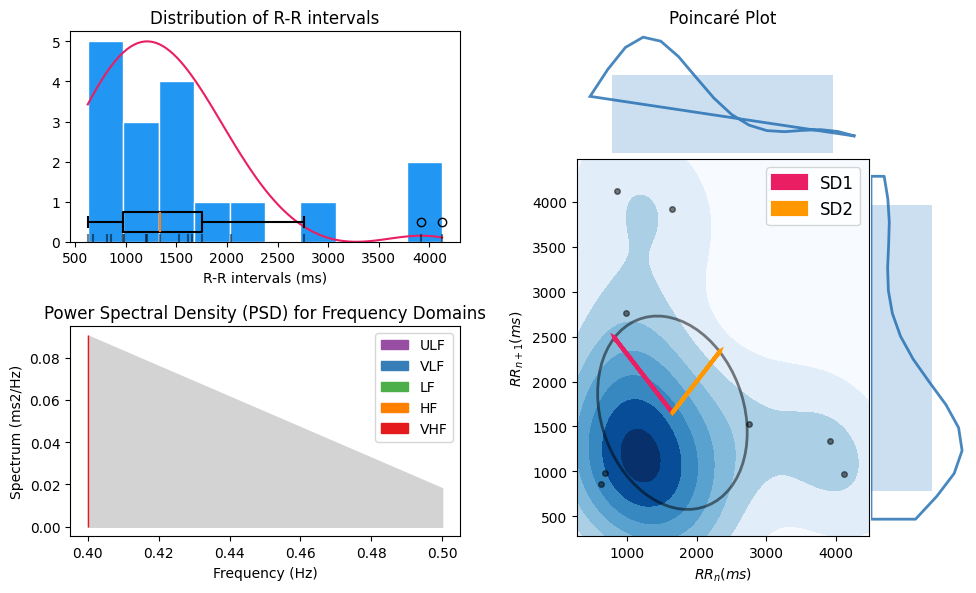


HRV Metrics Summary:


,HRV_MeanNN,HRV_SDNN,HRV_SDANN1,HRV_SDNNI1,HRV_SDANN2,HRV_SDNNI2,HRV_SDANN5,HRV_SDNNI5,HRV_RMSSD,HRV_SDSD,...,HRV_CMSEn,HRV_RCMSEn,HRV_CD,HRV_HFD,HRV_KFD,HRV_LZC,HRV_Symbolic_EqualProb4_0V,HRV_Symbolic_EqualProb4_1V,HRV_Symbolic_EqualProb4_2LV,HRV_Symbolic_EqualProb4_2UV
0,1652.411765,1041.933498,NaN,NaN,NaN,NaN,NaN,NaN,1615.739242,1668.717861,...,NaN,NaN,1.710083,NaN,4.101927,1.202195,0.0,0.266667,0.2,0.533333


In [ ]:
def calculate_hrv_metrics(rpeaks_data, sampling_rate):
    """Calculate HRV metrics using NeuroKit2"""
    hrv_metrics = []
    
    for epoch in rpeaks_data:
        if len(epoch['rr_intervals']) >= 2:  # Need at least 2 beats for HRV

            hrv_indices_pre = nk.hrv(epoch['rpeak_indices'], sampling_rate=sampling_rate, show=True)

            fig = plt.gcf()
            fig.set_size_inches(10, 6)
            plt.subplots_adjust(hspace=0.4, wspace=0.3) 
            plt.show()
            
            # Combine all metrics
            trial_metrics = pd.concat([hrv_indices_pre], axis=1)
            hrv_metrics.append(trial_metrics)
        else:
            print(f"Trial {epoch['trial_num']}: Insufficient beats for HRV ({len(epoch['rr_intervals'])} intervals)")
    
    if hrv_metrics:
        return pd.concat(hrv_metrics)
    else:
        return pd.DataFrame()

# Calculate HRV metrics
hrv_results = calculate_hrv_metrics(rpeaks_data, raw.info["sfreq"])
print("\nHRV Metrics Summary:")
hrv_results

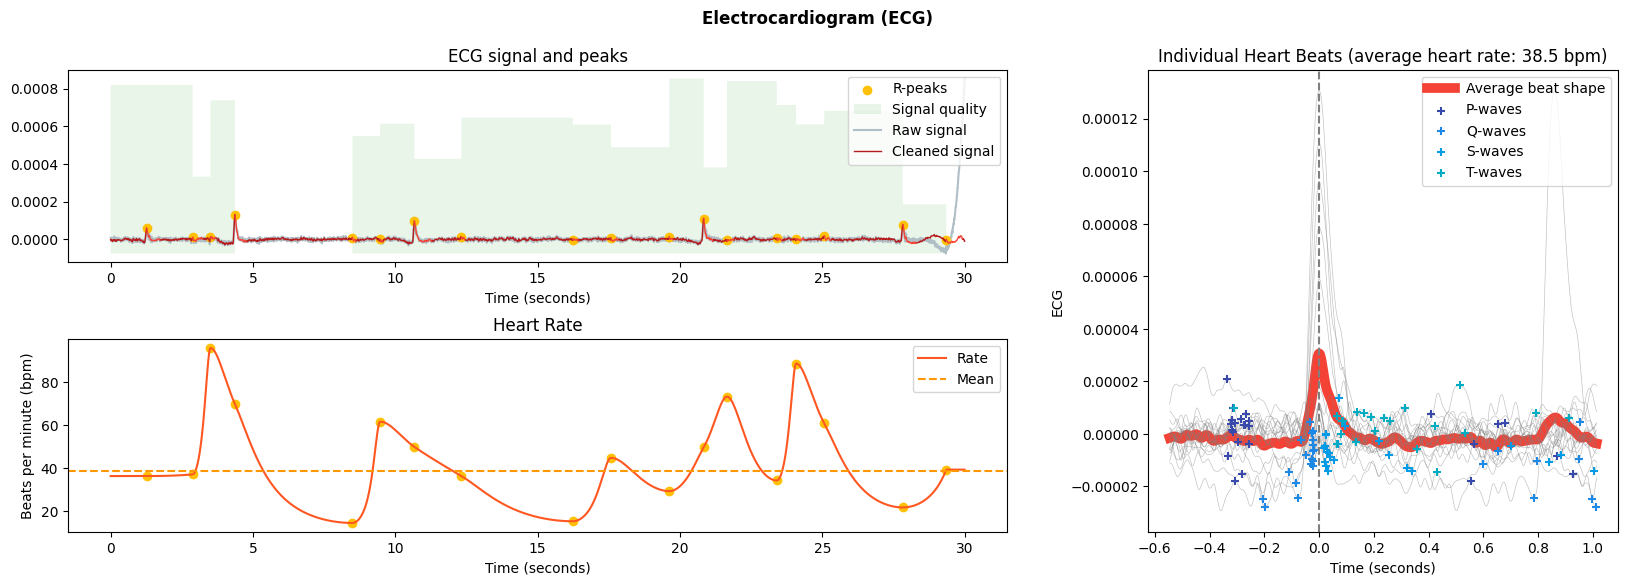

Processed 1 epochs


In [63]:
processed_post_epochs = process_ecg_epochs(stim_epochs[:1], raw.info["sfreq"])
print(f"Processed {len(processed_post_epochs)} epochs")